# SNR Comparison

Compare SNR distributions and summary statistics for Macaque, MoisesDB, and Bandit EV results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [10]:
# File paths
macaque_path = '../data/logs/e2e/test/2JB0ZX/lightning_logs/version_0/metrics.csv'
moisesdb_path = '../data/logs/e2e/test/7P21AG/lightning_logs/version_0/metrics.csv'
bandit_ev_path = '../third_party/query-bandit/reproducibility/results/query/bandit_ev.csv'

# Helper to extract all SNR columns for model results
def get_snr_cols(df):
    # Select all columns ending with '/snr/SafeSignalNoiseRatio'
    return [col for col in df.columns if col.endswith('/snr/SafeSignalNoiseRatio')]

def load_and_standarize(path, label):
    df = pd.read_csv(path)
    if label == 'Macaque':
        # Use PredictedDecibels, actual dB values
        col = 'test/target/snr/PredictedDecibels'
        snr_values = df[col].dropna()
        snr_values = snr_values[np.isfinite(snr_values)]
        return pd.DataFrame({'SNR': snr_values.astype(float), 'dataset': label})
    
    elif label == 'MoisesDB':
        snr_cols = get_snr_cols(df)
        snr_values = pd.concat([df[col] for col in snr_cols], ignore_index=True)
        snr_values = snr_values[pd.notnull(snr_values) & np.isfinite(snr_values)]
        return pd.DataFrame({'SNR': snr_values.astype(float), 'dataset': label})
    
    elif label == 'Bandit EV':
        snr_col = 'snr' if 'snr' in df.columns else df.columns[0]
        snr_values = df[snr_col].dropna()
        snr_values = snr_values[np.isfinite(snr_values)]
        return pd.DataFrame({'SNR': snr_values.astype(float), 'dataset': label})

macaque = load_and_standarize(macaque_path, 'Macaque')
moisesdb = load_and_standarize(moisesdb_path, 'MoisesDB')
bandit_ev = load_and_standarize(bandit_ev_path, 'Bandit EV')

all_results = pd.concat([macaque, moisesdb, bandit_ev], ignore_index=True)


In [11]:
# Summary statistics
summary = all_results.groupby('dataset')['SNR'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
display(summary)

,mean,median,std,min,max,count
dataset,,,,,,
Bandit EV,4.240059,3.059238,5.118803,-14.719251,18.090504,3010
Macaque,-113.756178,-119.842258,10.786614,-119.999893,-76.934586,200
MoisesDB,4.516511,3.292211,5.714477,-14.960411,16.500429,301


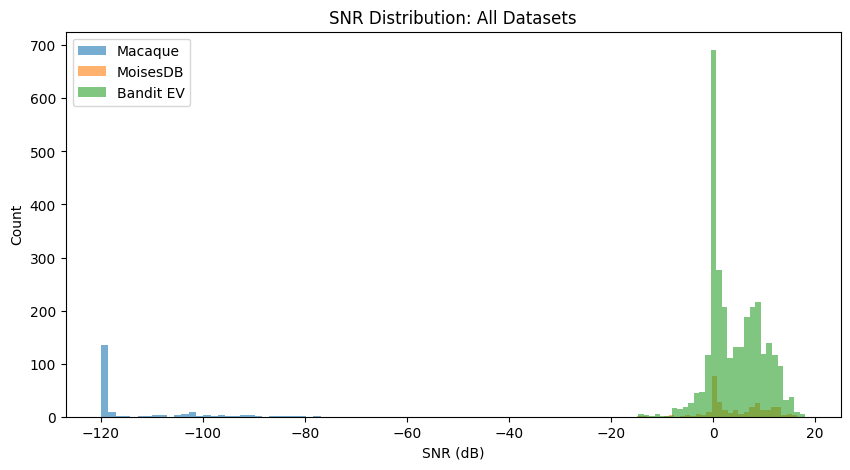

In [12]:
# Plot distributions
plt.figure(figsize=(10,5))
for dataset in all_results['dataset'].unique():
    subset = all_results[all_results['dataset'] == dataset]
    plt.hist(subset['SNR'], bins=30, alpha=0.6, label=dataset)
plt.xlabel('SNR (dB)')
plt.ylabel('Count')
plt.title('SNR Distribution: All Datasets')
plt.legend()
plt.show()

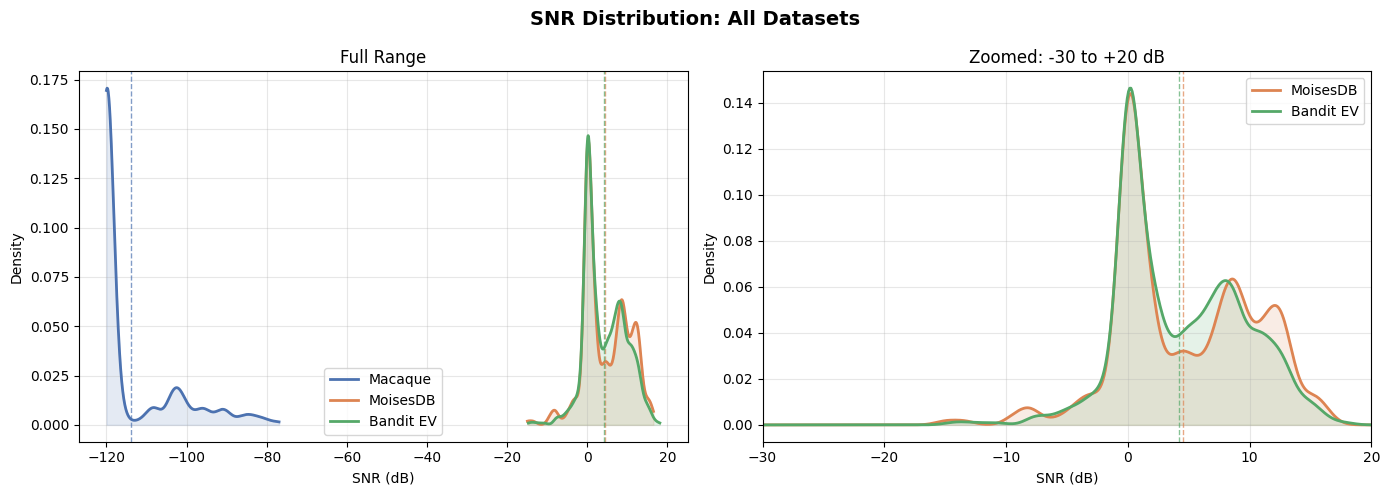

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SNR Distribution: All Datasets', fontsize=14, fontweight='bold')

colors = {'Macaque': '#4C72B0', 'MoisesDB': '#DD8452', 'Bandit EV': '#55A868'}

for ax, (xlim, title) in zip(axes, [
    (None,        'Full Range'),
    ((-30, 20),   'Zoomed: -30 to +20 dB'),
]):
    for dataset, color in colors.items():
        subset = all_results[all_results['dataset'] == dataset]['SNR'].values
        
        # Apply xlim filter for zoomed panel
        if xlim:
            subset = subset[(subset >= xlim[0]) & (subset <= xlim[1])]
        
        if len(subset) < 2:
            continue
        
        kde = gaussian_kde(subset, bw_method=0.15)
        x = np.linspace(subset.min(), subset.max(), 500) if not xlim else np.linspace(*xlim, 500)
        ax.plot(x, kde(x), label=dataset, color=color, linewidth=2)
        ax.fill_between(x, kde(x), alpha=0.15, color=color)
        
        # Mean line
        ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1, alpha=0.7)

    if xlim:
        ax.set_xlim(xlim)
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()